<a href="https://colab.research.google.com/github/Abinath7/Abinath7/blob/main/prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
from google.colab import files

uploaded = files.upload()


Saving diabetic_patients_dataset.csv to diabetic_patients_dataset.csv


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [16]:
import pandas as pd
import numpy as np


df=pd.read_csv("diabetic_patients_dataset.csv")


df.head()



,PatientID,VisitNumber,VisitDate,Age,Glucose,HbA1c,BloodPressure,BMI,Insulin,MedicationAdherence,ExerciseLevel,DietQuality,RecoveryStatus
0,P0001,1,2022-06-01,58,183.3,8.32,135.3,38.48,162.0,Poor,Low,Moderate,Stable
1,P0001,2,2022-07-14,58,198.0,8.50,136.9,38.60,165.5,Poor,Low,Moderate,Deteriorating
2,P0001,3,2022-08-15,58,203.7,8.67,136.5,39.02,169.4,Poor,Low,Moderate,Deteriorating
3,P0001,4,2022-09-26,58,212.5,8.73,139.7,39.13,172.2,Poor,Low,Moderate,Deteriorating
4,P0001,5,2022-10-27,58,224.3,9.07,141.5,39.39,171.5,Poor,Low,Moderate,Deteriorating


In [22]:
print("Shape:", df.shape)           # rows × columns
print("\nFirst 5 rows:")
df.head()

Shape: (1778, 13)

First 5 rows:


,PatientID,VisitNumber,VisitDate,Age,Glucose,HbA1c,BloodPressure,BMI,Insulin,MedicationAdherence,ExerciseLevel,DietQuality,RecoveryStatus
0,P0001,1,2022-06-01,58,183.3,8.32,135.3,38.48,162.0,Poor,Low,Moderate,Stable
1,P0001,2,2022-07-14,58,198.0,8.50,136.9,38.60,165.5,Poor,Low,Moderate,Deteriorating
2,P0001,3,2022-08-15,58,203.7,8.67,136.5,39.02,169.4,Poor,Low,Moderate,Deteriorating
3,P0001,4,2022-09-26,58,212.5,8.73,139.7,39.13,172.2,Poor,Low,Moderate,Deteriorating
4,P0001,5,2022-10-27,58,224.3,9.07,141.5,39.39,171.5,Poor,Low,Moderate,Deteriorating


In [17]:
df.tail()

,PatientID,VisitNumber,VisitDate,Age,Glucose,HbA1c,BloodPressure,BMI,Insulin,MedicationAdherence,ExerciseLevel,DietQuality,RecoveryStatus
1773,P0400,2,2022-11-19,73,263.7,10.90,159.7,31.81,180.3,Good,High,Good,Improving
1774,P0400,3,2022-12-26,73,255.7,10.86,162.8,31.88,189.5,Good,High,Good,Stable
1775,P0400,4,2023-01-25,73,254.3,10.84,161.7,32.03,184.4,Good,High,Good,Stable
1776,P0400,5,2023-02-24,73,243.6,10.85,165.4,32.15,182.2,Good,High,Good,Stable
1777,P0400,6,2023-03-30,73,241.7,10.79,167.2,32.30,186.5,Good,High,Good,Stable


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1778 entries, 0 to 1777
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PatientID            1778 non-null   object 
 1   VisitNumber          1778 non-null   int64  
 2   VisitDate            1778 non-null   object 
 3   Age                  1778 non-null   int64  
 4   Glucose              1778 non-null   float64
 5   HbA1c                1778 non-null   float64
 6   BloodPressure        1778 non-null   float64
 7   BMI                  1778 non-null   float64
 8   Insulin              1778 non-null   float64
 9   MedicationAdherence  1778 non-null   object 
 10  ExerciseLevel        1778 non-null   object 
 11  DietQuality          1778 non-null   object 
 12  RecoveryStatus       1778 non-null   object 
dtypes: float64(5), int64(2), object(6)
memory usage: 180.7+ KB


In [23]:
df.describe().round(2)

,VisitNumber,Age,Glucose,HbA1c,BloodPressure,BMI,Insulin
count,1778.00,1778.00,1778.00,1778.00,1778.00,1778.00,1778.00
mean,2.86,49.51,226.88,9.81,152.46,33.84,141.44
std,1.46,17.81,39.08,1.25,13.51,3.75,36.48
min,1.00,20.00,120.20,6.46,115.80,26.40,63.50
25%,2.00,35.00,197.82,8.80,141.70,30.55,111.50
50%,3.00,47.00,228.40,9.83,153.40,34.10,140.00
75%,4.00,66.00,256.55,10.84,163.10,37.25,171.10
max,6.00,80.00,337.00,12.67,184.00,41.26,230.30


In [20]:
df.isnull().sum()

,0
PatientID,0
VisitNumber,0
VisitDate,0
Age,0
Glucose,0
HbA1c,0
BloodPressure,0
BMI,0
Insulin,0
MedicationAdherence,0


In [24]:
print("RecoveryStatus counts:")
print(df['RecoveryStatus'].value_counts())

RecoveryStatus counts:
RecoveryStatus
Deteriorating    773
Stable           545
Improving        387
Recovering        73
Name: count, dtype: int64


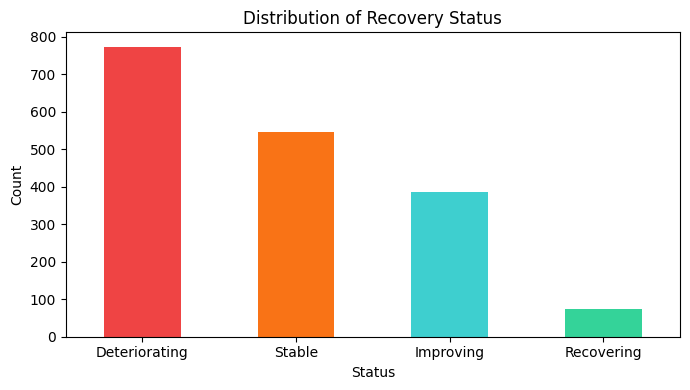

In [25]:
plt.figure(figsize=(7, 4))
df['RecoveryStatus'].value_counts().plot(kind='bar', color=['#ef4444','#f97316','#3ecfcf','#34d399'])
plt.title('Distribution of Recovery Status')
plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()